In [1]:
from collections import defaultdict

import numpy as np

import torch
import blobfile as bf
import transformer_lens
import sparse_autoencoder

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32
torch.set_default_dtype(dtype)

In [3]:
model = transformer_lens.HookedTransformer.from_pretrained("gpt2", center_writing_weights=False)
# device = next(model.parameters()).device

Loaded pretrained model gpt2 into HookedTransformer


In [5]:
prompt = "This is an example of a prompt that"
tokens = model.to_tokens(prompt)  # (1, n_tokens)
with torch.no_grad():
    logits, activation_cache = model.run_with_cache(tokens, remove_batch_dim=True)

layer_index = 7
location = "resid_post_mlp"

transformer_lens_loc = {
    "mlp_post_act": f"blocks.{layer_index}.mlp.hook_post",
    "resid_delta_attn": f"blocks.{layer_index}.hook_attn_out",
    "resid_post_attn": f"blocks.{layer_index}.hook_resid_mid",
    "resid_delta_mlp": f"blocks.{layer_index}.hook_mlp_out",
    "resid_post_mlp": f"blocks.{layer_index}.hook_resid_post",
}[location]

with bf.BlobFile(sparse_autoencoder.paths.v5_32k(location, layer_index), mode="rb") as f:
    state_dict = torch.load(f)
    autoencoder = sparse_autoencoder.Autoencoder.from_state_dict(state_dict)
    autoencoder.to(device)

input_tensor = activation_cache[transformer_lens_loc]

input_tensor_ln = input_tensor

with torch.no_grad():
    latent_activations, info = autoencoder.encode(input_tensor_ln)
    reconstructed_activations = autoencoder.decode(latent_activations, info)

normalized_mse = (reconstructed_activations - input_tensor).pow(2).sum(dim=1) / (input_tensor).pow(2).sum(dim=1)
print(location, normalized_mse)

resid_post_mlp tensor([6.3525e-05, 3.8419e-02, 2.8748e-02, 4.9353e-02, 9.7877e-02, 5.5597e-02,
        6.0144e-02, 5.6684e-02, 7.4793e-02], device='cuda:0')


In [6]:
W_dec = autoencoder.decoder.weight.data.clone()

In [7]:
W_dec.shape

torch.Size([768, 32768])

In [32]:
# let's learn a low-rank approximation of W_dec
d, n = W_dec.shape
ranks = [32, 64, 128, 256, 512, 768, 1024]

steps = list(range(5_000))
losses = defaultdict(list)

for rank in tqdm(ranks):
    var_W_dec = torch.var(W_dec)
    scaling = (var_W_dec / 2).sqrt()
    W1 = torch.randn(d, rank, device=device, dtype=dtype) * (scaling / np.sqrt(rank))
    W1 = W1.requires_grad_(True)
    W2 = torch.randn(rank, n, device=device, dtype=dtype) * (scaling / np.sqrt(rank))
    W2 = W2.requires_grad_(True)

    optimizer = torch.optim.Adam([W1, W2], lr=1e-3)

    for step in steps:
        optimizer.zero_grad()
        W_dec_approx = W1 @ W2
        loss = (W_dec - W_dec_approx).pow(2).mean()
        loss.backward()
        optimizer.step()
        losses[rank].append(loss.item())

  0%|          | 0/7 [00:00<?, ?it/s]

Text(0, 0.5, 'MSE (of reconstructing W_dec, not the activations)')

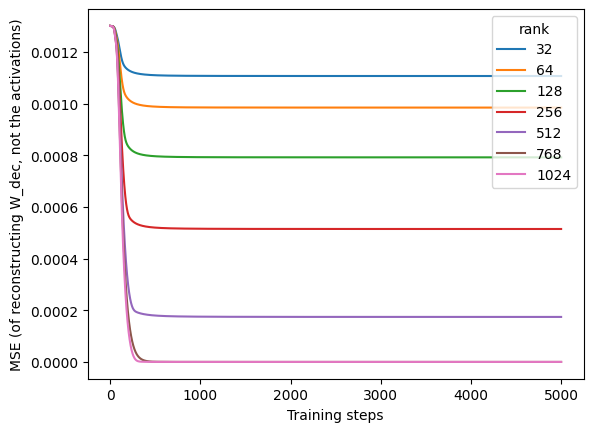

In [37]:
for rank in ranks:
    plt.plot(steps, losses[rank], label=rank)
plt.legend(title="rank", loc='upper right')
plt.xlabel("Training steps")
plt.ylabel("MSE (of reconstructing W_dec, not the activations)")

### plot some statistics about the non-randomness of SAE vectors

In [9]:
d, n = W_dec.shape
W_dec_random = torch.randn(d, n, device=device, dtype=dtype)
# normalize
W_dec_random /= W_dec_random.norm(dim=0, keepdim=True)

In [17]:
W_dec.device

device(type='cuda', index=0)

In [18]:
W_dec.shape

torch.Size([768, 32768])

In [19]:
# pairwise dot products
pairwise_dot_products_random = W_dec_random.t() @ W_dec_random
pairwise_dot_products_sae = W_dec.t() @ W_dec

In [21]:
# use numpy to compute histograms
hist_random, bin_edges = np.histogram(pairwise_dot_products_random.flatten().cpu().numpy(), bins=300, range=(-1, 1))
hist_sae, _ = np.histogram(pairwise_dot_products_sae.flatten().cpu().numpy(), bins=300, range=(-1, 1))

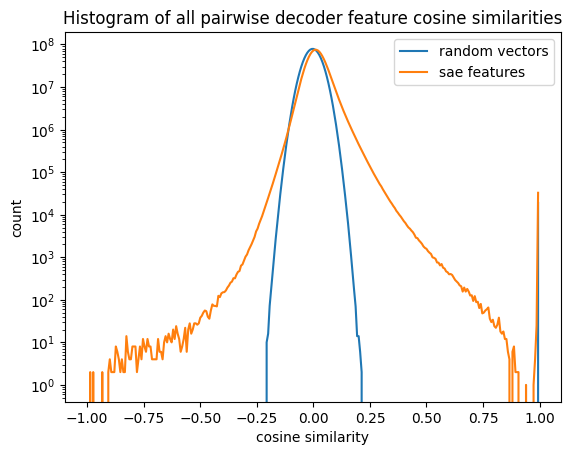

In [27]:
plt.plot(bin_edges[:-1], hist_random, label="random vectors")
plt.plot(bin_edges[:-1], hist_sae, label="sae features")
plt.yscale('log')
plt.xlabel("cosine similarity")
plt.ylabel("count")
plt.title("Histogram of all pairwise decoder feature cosine similarities")
plt.legend()

In [30]:
# plot the maximum pairwise cosine similarity for each feature, excluding self-similarity
pairwise_dot_products_random_noself = pairwise_dot_products_random.clone().cpu().numpy()
np.fill_diagonal(pairwise_dot_products_random_noself, -2)
max_cosine_similarity_random = pairwise_dot_products_random_noself.max(axis=0)

pairwise_dot_products_sae_noself = pairwise_dot_products_sae.clone().cpu().numpy()
np.fill_diagonal(pairwise_dot_products_sae_noself, -2)
max_cosine_similarity_sae = pairwise_dot_products_sae_noself.max(axis=0)

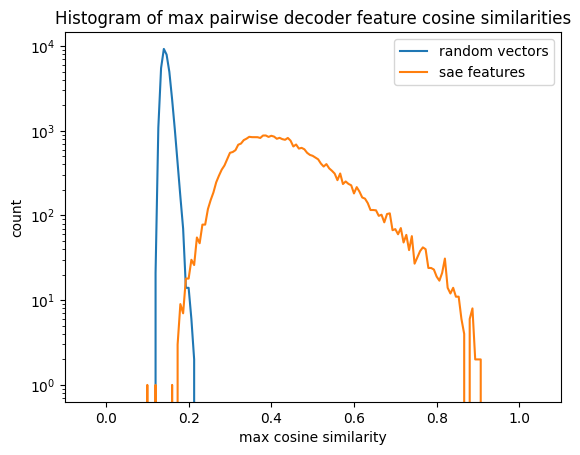

In [34]:
# use numpy again
hist_random_max, bin_edges_max = np.histogram(max_cosine_similarity_random, bins=300, range=(-1, 1))
hist_sae_max, _ = np.histogram(max_cosine_similarity_sae, bins=300, range=(-1, 1))

plt.plot(bin_edges_max[:-1], hist_random_max, label="random vectors")
plt.plot(bin_edges_max[:-1], hist_sae_max, label="sae features")
plt.yscale('log')
plt.xlabel("max cosine similarity")
plt.ylabel("count")
plt.title("Histogram of max pairwise decoder feature cosine similarities")
plt.xlim(-0.1, 1.1)
plt.legend()

In [36]:
# compute spectrum of both pairwise_dot_products_random and pairwise_dot_products_sae, use torch
spectrum_random = torch.linalg.eigvalsh(pairwise_dot_products_random)
spectrum_sae = torch.linalg.eigvalsh(pairwise_dot_products_sae)

In [48]:
# plot distribution over eigenvalues, use numpy
hist_spectrum_random, bin_edges_spectrum = np.histogram(spectrum_random.cpu().numpy(), bins=500, range=(0, 1000))
hist_spectrum_sae, _ = np.histogram(spectrum_sae.cpu().numpy(), bins=500, range=(0, 1000))

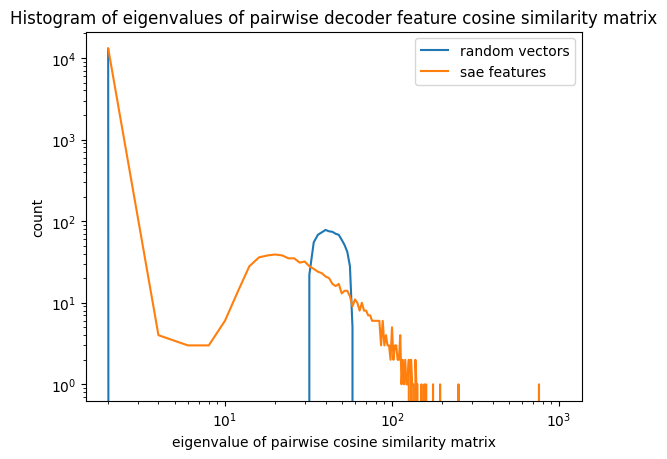

In [49]:
plt.plot(bin_edges_spectrum[1:], hist_spectrum_random, label="random vectors")
plt.plot(bin_edges_spectrum[1:], hist_spectrum_sae, label="sae features")
plt.yscale('log')
plt.xlabel("eigenvalue of pairwise cosine similarity matrix")
plt.ylabel("count")
plt.title("Histogram of eigenvalues of pairwise decoder feature cosine similarity matrix")
plt.xscale('log')
plt.legend()

## Repeat for 128k

In [5]:
prompt = "This is an example of a prompt that"
tokens = model.to_tokens(prompt)  # (1, n_tokens)
with torch.no_grad():
    logits, activation_cache = model.run_with_cache(tokens, remove_batch_dim=True)

layer_index = 7
location = "resid_post_mlp"

transformer_lens_loc = {
    "mlp_post_act": f"blocks.{layer_index}.mlp.hook_post",
    "resid_delta_attn": f"blocks.{layer_index}.hook_attn_out",
    "resid_post_attn": f"blocks.{layer_index}.hook_resid_mid",
    "resid_delta_mlp": f"blocks.{layer_index}.hook_mlp_out",
    "resid_post_mlp": f"blocks.{layer_index}.hook_resid_post",
}[location]

with bf.BlobFile(sparse_autoencoder.paths.v5_128k(location, layer_index), mode="rb") as f:
    state_dict = torch.load(f)
    autoencoder = sparse_autoencoder.Autoencoder.from_state_dict(state_dict)
    autoencoder.to(device)

input_tensor = activation_cache[transformer_lens_loc]

input_tensor_ln = input_tensor

with torch.no_grad():
    latent_activations, info = autoencoder.encode(input_tensor_ln)
    reconstructed_activations = autoencoder.decode(latent_activations, info)

normalized_mse = (reconstructed_activations - input_tensor).pow(2).sum(dim=1) / (input_tensor).pow(2).sum(dim=1)
print(location, normalized_mse)

resid_post_mlp tensor([4.4261e-05, 3.4128e-02, 2.7765e-02, 4.3691e-02, 6.7675e-02, 5.0844e-02,
        5.6018e-02, 3.3690e-02, 5.7836e-02], device='cuda:0')


In [6]:
W_dec = autoencoder.decoder.weight.data.clone()
W_dec.shape

torch.Size([768, 131072])

In [12]:
W_dec.shape

torch.Size([768, 131072])

In [13]:
W_dec.shape

torch.Size([768, 131072])

In [20]:
W_dec_np = W_dec.cpu().numpy()
W_dec_np = W_dec_np / np.linalg.norm(W_dec_np, axis=0, keepdims=True)

In [24]:
np.linalg.norm(W_dec_np, axis=0)[:10]

array([1.0000001 , 0.9999995 , 1.0000001 , 0.9999995 , 1.0000001 ,
       1.0000002 , 0.99999994, 1.0000001 , 1.        , 0.99999994],
      dtype=float32)

In [52]:
from sklearn.linear_model import OrthogonalMatchingPursuit

In [55]:
cos_sims = []
for featurei in tqdm(range(1_000)):
    omp = OrthogonalMatchingPursuit(n_nonzero_coefs=2, fit_intercept=False)
    dictionary = np.delete(W_dec_np, featurei, axis=1)
    results = omp.fit(dictionary, W_dec_np[:, featurei])

    # compute cosine sim between (dictionary @ results.coef_) and W_dec_np[:, featurei]
    recon = dictionary @ results.coef_
    recon_unit = recon / np.linalg.norm(recon)
    cos_sims.append(np.dot(recon, W_dec_np[:, featurei]))

  0%|          | 0/1000 [00:00<?, ?it/s]

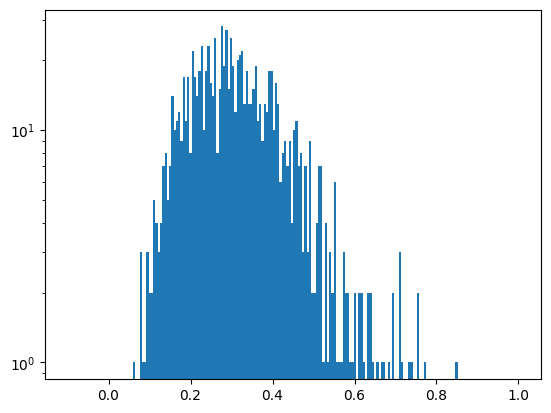

In [56]:
# plot distribution over cosine similarities
_ = plt.hist(cos_sims, bins=200, range=(-0.1, 1), log=True)

In [31]:
results.score

<bound method RegressorMixin.score of OrthogonalMatchingPursuit(fit_intercept=False, n_nonzero_coefs=2)>

In [17]:
find_best_pair_omp(W_dec.cpu().numpy(), 0, 2)

TypeError: OrthogonalMatchingPursuit.__init__() got an unexpected keyword argument 'normalize'